In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy.stats import t, shapiro, levene, ttest_ind

In [29]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame = True)
df = wine.frame 

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [30]:
df = df[df['target'].isin([0,1])]

/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_2179/1275585927.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'target', y = 'alcohol', data=df, palette='Set2')


<Axes: xlabel='target', ylabel='alcohol'>

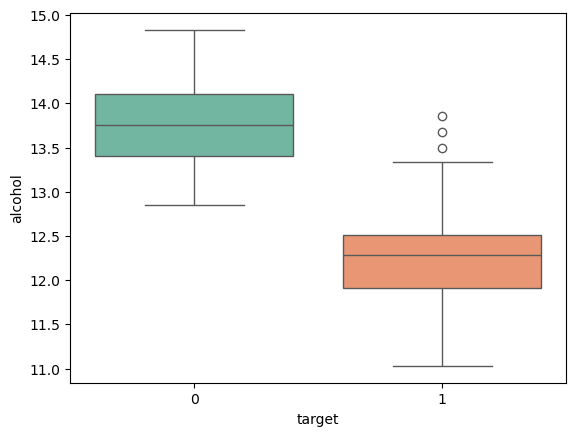

In [32]:
sns.boxplot(x = 'target', y = 'alcohol', data=df, palette='Set2')

In [33]:
# H0 : 0과 1의 평균 알코올 함량이 같다.
# H1 : 0과 1의 평균 알코올 함량이 다르다.

In [34]:
a0 = df[df['target'] == 0]['alcohol']
a1 = df[df['target'] == 1]['alcohol']

In [35]:
# 정규성
print(shapiro(a0)) # p-value > 0.05 --> 정규성 만족
print(shapiro(a1)) # p-value > 0.05 --> 정규성 만족

ShapiroResult(statistic=0.9808939732940862, pvalue=0.47906805750231335)
ShapiroResult(statistic=0.9720515958359174, pvalue=0.11396072209600777)


In [36]:
levene(a1, a1) #등분산 가정 만족

LeveneResult(statistic=0.0, pvalue=1.0)

In [38]:
ttest_ind(a0, a1, equal_var = True)
# p-value < 0.05 --> H0 기각 --> 0과 1 사이의 알코올 함량의 평균이 통계적으로 유의미하게 다르다

TtestResult(statistic=16.478551495156527, pvalue=1.9551698789379198e-33, df=128.0)

In [39]:
df = pd.read_csv('paired_ttest.csv')
df.head()

,subject,age,gender,group,score_before,score_after
0,1,22,Female,Control,72.602923,76.621921
1,2,48,Male,Control,62.157335,65.288799
2,3,54,Male,Control,50.098954,49.453684
3,4,58,Male,Control,72.295027,74.936191
4,5,37,Female,Treatment,71.925477,79.723112


In [47]:
control = df[df['group'] == 'Control']
treatment = df[df['group'] == 'Treatment']

control_before = control['score_before']
control_after = control['score_after']

treatment_before = treatment['score_before']
treatment_after = treatment['score_after']

In [48]:
summary_df = pd.DataFrame({
    'group': ['Control', 'Control', 'Treatment', 'Treatment'],
    'time': ['Before', 'after', 'Before' , 'after'],
    'score': [
        control_before.mean(),
        control_after.mean(),
        treatment_before.mean(),
        treatment_after.mean()
    ]
})

In [49]:
summary_df

,group,time,score
0,Control,Before,65.279914
1,Control,after,69.472824
2,Treatment,Before,65.354093
3,Treatment,after,69.454541


<Axes: xlabel='group', ylabel='score'>

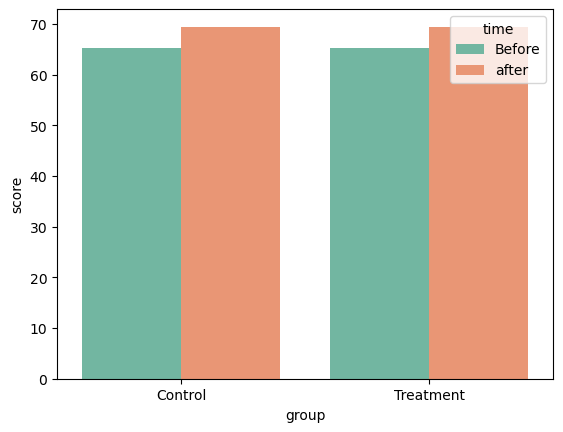

In [50]:
sns.barplot(summary_df, x = 'group', y = 'score', hue = 'time', palette='Set2')

In [51]:
from scipy.stats import ttest_rel

In [52]:
print(shapiro(control_before))   # 정규성 만족
print(shapiro(control_after))
print(shapiro(treatment_before))
print(shapiro(treatment_after))

ShapiroResult(statistic=0.9894673532582197, pvalue=0.35665400720199397)
ShapiroResult(statistic=0.9828880100252413, pvalue=0.0714790609526649)
ShapiroResult(statistic=0.990387761838582, pvalue=0.365685031062183)
ShapiroResult(statistic=0.9913115314746922, pvalue=0.4547402923622468)


In [53]:
ttest_rel(control_before, control_after)

ttest_rel(treatment_before, treatment_after)

TtestResult(statistic=-25.39392781558671, pvalue=2.739843047575311e-57, df=156)

In [54]:
from scipy.stats import f

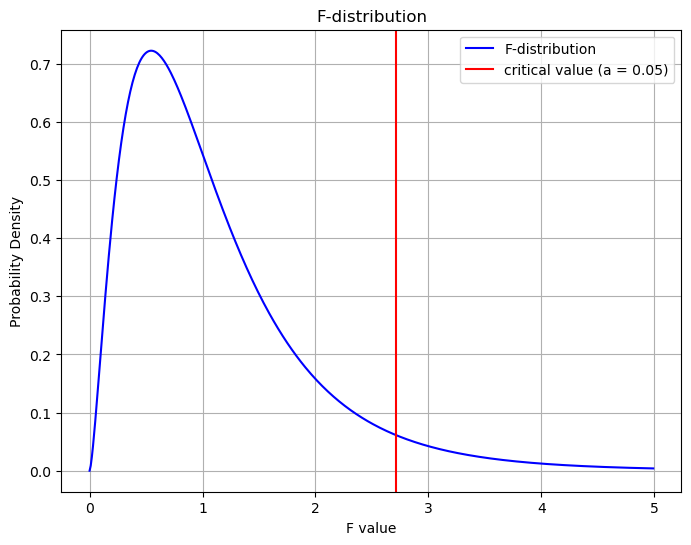

In [16]:
df1 = 5
df2 = 20

x = np.arange(0,5,0.01)
y = f.pdf(x, df1, df2)

plt.figure(figsize=(8,6))
plt.plot(x, y, label='F-distribution', color = 'blue')

critical_val = f.ppf(0.95, df1, df2)
plt.axvline(critical_val, color='red', linestyle='-', label='critical value (a = 0.05)')

plt.title('F-distribution')
plt.xlabel('F value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

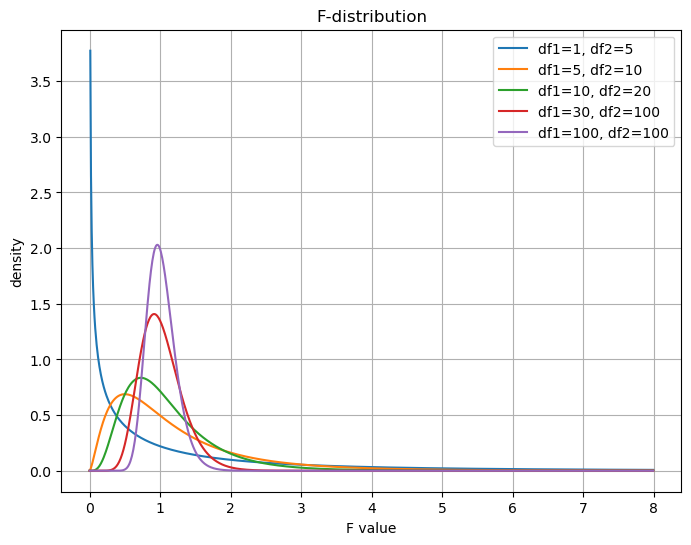

In [17]:
x = np.arange(0,8,0.01)
alpha = 0.05

df_combinations = [(1,5), (5,10), (10,20), (30,100), (100,100)]

plt.figure(figsize=(8,6))

for df1, df2 in df_combinations :
    y = f.pdf(x, df1, df2)
    plt.plot(x, y, label=f'df1={df1}, df2={df2}')
    
plt.title('F-distribution')
plt.xlabel('F value')
plt.ylabel('density')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
df1 = 10
df2 = 20
alpha = 0.05

x = np.arange(0, 5, 0.01)
y = f.pdf(x, df1, df2)

f.ppf(1 - alpha, df1, df2)

2.3478775669983114

In [20]:
f_value = f.ppf(1 - alpha, df1, df2)

In [21]:
iris = sns.load_dataset('iris')

/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_2179/1813412035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'species', y = 'sepal_length', data = iris_subset, palette='Set2')


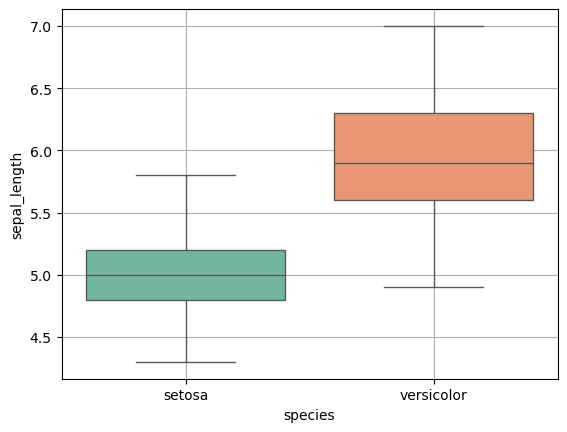

In [55]:
iris_subset = iris[iris['species'].isin(['setosa', 'versicolor'])]

sns.boxplot(x = 'species', y = 'sepal_length', data = iris_subset, palette='Set2')
plt.grid(True)
plt.show()

In [56]:
# H0 : setosa와 versi의 sepal_length 분산이 같다.
# H1 : ///// 다르다.

In [57]:
setosa = iris[iris['species'] == 'setosa']['sepal_length']
versicolor = iris[iris['species'] == 'versicolor']['sepal_length']

In [58]:
shapiro(setosa)

ShapiroResult(statistic=0.977698549796646, pvalue=0.4595131499174534)

In [59]:
shapiro(versicolor)

ShapiroResult(statistic=0.9778356785897524, pvalue=0.46473703592503574)

In [60]:
s1_var = np.var(versicolor, ddof=1)
s2_var = np.var(setosa, ddof=1)
print(s1_var)
print(s2_var)

0.2664326530612246
0.12424897959183662


In [61]:
F_stat = s1_var / s2_var

df1 = len(versicolor) - 1
df2 = len(setosa) - 1

p_val = 1 - f.cdf(F_stat, df1, df2)
print(F_stat)
print(p_val)

2.144344798134098
0.0043285941813498985


In [82]:
# 예제 1
from sklearn.datasets import load_wine
wine = load_wine(as_frame = True)
df = wine.frame

In [63]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_2179/3131794620.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'target', y = 'alcohol', data = df, palette='Set2')


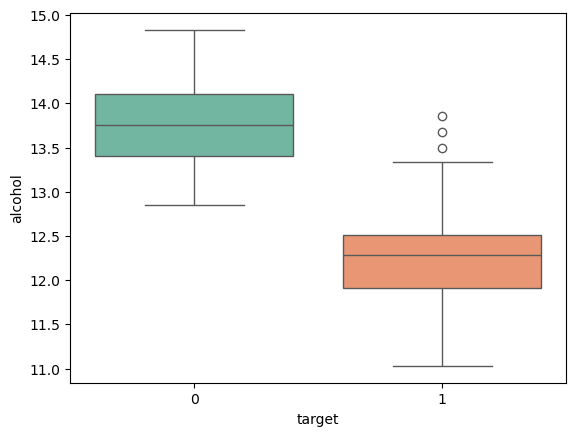

In [71]:
df = df[df['target'].isin([0,1])]
sns.boxplot(x = 'target', y = 'alcohol', data = df, palette='Set2')
plt.show()

In [85]:
target0 = df[df['target'] == 0]['alcohol']
target1 = df[df['target'] == 1]['alcohol']

In [86]:
shapiro(target0)

ShapiroResult(statistic=0.9808939732940862, pvalue=0.47906805750231335)

In [87]:
shapiro(target1)

ShapiroResult(statistic=0.9720515958359174, pvalue=0.11396072209600777)

In [88]:
s0_var = np.var(target0, ddof=1)
s1_var = np.var(target1, ddof=1)

print(s0_var)
print(s1_var)

0.21355984804208064
0.28940551307847084


In [89]:
F_stat = s1_var / s0_var

df0 = len(target0) - 1
df1 = len(target1) - 1

In [90]:
p_val = 1 - f.cdf(F_stat, df1, df2)

In [91]:
print(f"F-satistic : {F_stat:.4f}")
print(f"p-value : {p_val:.4f}")

F-satistic : 1.3551
p-value : 0.1311


In [3]:
# 예제 2
import pandas as pd 

paired = pd.read_csv('paired_ttest.csv')
paired

,subject,age,gender,group,score_before,score_after
0,1,22,Female,Control,72.602923,76.621921
1,2,48,Male,Control,62.157335,65.288799
2,3,54,Male,Control,50.098954,49.453684
3,4,58,Male,Control,72.295027,74.936191
4,5,37,Female,Treatment,71.925477,79.723112
...,...,...,...,...,...,...
295,296,26,Male,Control,64.640744,70.927059
296,297,56,Female,Control,59.874411,66.206970
297,298,46,Male,Control,57.660705,60.308753
298,299,27,Male,Treatment,61.904924,70.895475


In [5]:
treatment_paired = paired[paired['group'] == 'Treatment']

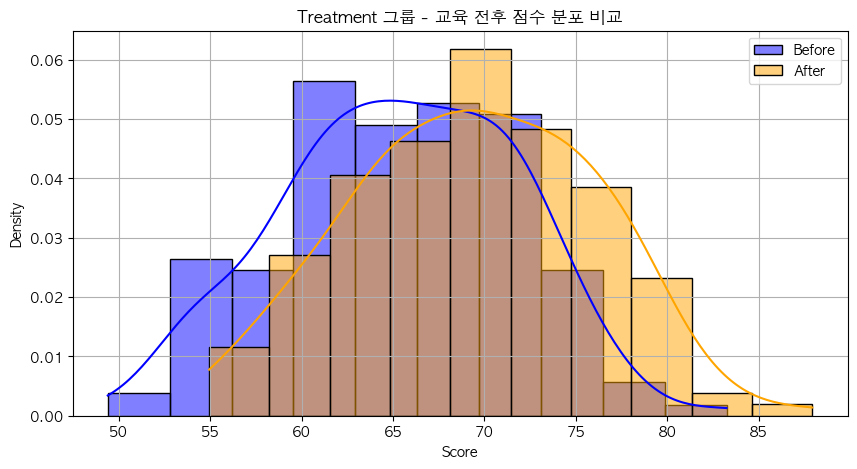

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns

# 폰트 깨짐 방지
plt.rcParams['font.family'] = 'AppleGothic' # Malgun Gothic

plt.figure(figsize=(10, 5))
sns.histplot(treatment_paired['score_before'], kde=True, color='blue', label='Before', stat='density')
sns.histplot(treatment_paired['score_after'], kde=True, color='orange', label='After', stat='density')
plt.title('Treatment 그룹 - 교육 전후 점수 분포 비교')
plt.xlabel('Score')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from scipy.stats import f

var_before = treatment_paired['score_before'].var(ddof=1)
var_after = treatment_paired['score_after'].var(ddof=1)

f_stat = var_before / var_after
df1 = len(treatment_paired['score_before']) - 1
df2 = len(treatment_paired['score_after']) - 1
p_value = 2 * min(f.cdf(f_stat, df1, df2), 1 - f.cdf(f_stat, df1, df2))  # 양측검정

In [12]:
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")

F-statistic: 0.9314
p-value: 0.6576
